## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models

## Load Dataset

In [3]:
dataset_path = Path("../dataset")
dl_data_path = dataset_path / "dl_data"

X_train = np.load(dl_data_path / "X_train.npy")
X_validation = np.load(dl_data_path / "X_validation.npy")
X_test = np.load(dl_data_path / "X_test.npy")

y_train = np.load(dl_data_path / "y_train.npy")
y_validation = np.load(dl_data_path / "y_validation.npy")
y_test = np.load(dl_data_path / "y_test.npy")

print("===== Datasets loaded successfully. =====")

===== Datasets loaded successfully. =====


## Preprocessing & Normalization

In [4]:
X_train = X_train.astype(np.float32)
X_validation = X_validation.astype(np.float32)
X_test = X_test.astype(np.float32)

# Calculate statistics only from training data
train_mean = X_train.mean()
train_std = X_train.std()

# Normalize
X_train = (X_train - train_mean) / train_std
X_validation = (X_validation - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("===== NORMALIZATION CHECK =====")

print("Train:")
print("Mean:", X_train.mean())
print("Std:", X_train.std())

print("\nValidation:")
print("Mean:", X_validation.mean())
print("Std:", X_validation.std())

print("\nTest:")
print("Mean:", X_test.mean())
print("Std:", X_test.std())

===== NORMALIZATION CHECK =====
Train:
Mean: 8.628554e-08
Std: 1.0000006

Validation:
Mean: 0.00015843338
Std: 1.0341631

Test:
Mean: 0.0026376029
Std: 1.0162377


## Add Channel Dimension

In [5]:
X_train = X_train[..., np.newaxis]
X_validation = X_validation[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("\n===== DENSENET INPUT SHAPES =====")

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)


===== DENSENET INPUT SHAPES =====
X_train: (5969, 9000, 1)
X_validation: (1279, 9000, 1)
X_test: (1280, 9000, 1)


## Dense Layer

In [6]:
def dense_layer(x, growth_rate=32, dropout_rate=0.0):
    
    # Batch Normalization
    x1 = layers.BatchNormalization()(x)
    
    # ReLU
    x1 = layers.Activation("relu")(x1)
    
    # 1x1 bottleneck convolution
    x1 = layers.Conv1D(
        filters=4 * growth_rate,
        kernel_size=1,
        padding="same",
        use_bias=False
    )(x1)
    
    # Batch Normalization
    x1 = layers.BatchNormalization()(x1)
    
    # ReLU
    x1 = layers.Activation("relu")(x1)
    
    # 3x1 convolution
    x1 = layers.Conv1D(
        filters=growth_rate,
        kernel_size=3,
        padding="same",
        use_bias=False
    )(x1)
    
    if dropout_rate > 0:
        x1 = layers.Dropout(dropout_rate)(x1)
    
    # Dense connection
    x = layers.Concatenate(axis=-1)([x, x1])
    
    return x

## Dense Block

In [7]:
def dense_block(
    x,
    num_layers=4,
    growth_rate=32,
    dropout_rate=0.0
):
    
    for _ in range(num_layers):
        
        x = dense_layer(
            x,
            growth_rate=growth_rate,
            dropout_rate=dropout_rate
        )
    
    return x

## Transition Block

In [8]:
def transition_block(x, compression=0.5):
    
    # Batch Normalization
    x = layers.BatchNormalization()(x)
    
    # ReLU
    x = layers.Activation("relu")(x)
    
    # Reduce number of channels
    channels = x.shape[-1]
    reduced_channels = int(channels * compression)
    
    x = layers.Conv1D(
        filters=reduced_channels,
        kernel_size=1,
        padding="same",
        use_bias=False
    )(x)
    
    # Downsampling
    x = layers.AveragePooling1D(
        pool_size=2,
        strides=2,
        padding="same"
    )(x)
    
    return x

## Build DenseNet-1D Model

In [9]:
inputs = layers.Input(
    shape=(9000, 1)
)

x = inputs


# =========================================================
# Initial Convolution
# =========================================================

x = layers.Conv1D(
    filters=64,
    kernel_size=7,
    strides=2,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

x = layers.MaxPooling1D(
    pool_size=3,
    strides=2,
    padding="same"
)(x)


# =========================================================
# Dense Block 1
# =========================================================

x = dense_block(
    x,
    num_layers=4,
    growth_rate=32,
    dropout_rate=0.0
)


# =========================================================
# Transition 1
# =========================================================

x = transition_block(
    x,
    compression=0.5
)


# =========================================================
# Dense Block 2
# =========================================================

x = dense_block(
    x,
    num_layers=4,
    growth_rate=32,
    dropout_rate=0.0
)


# =========================================================
# Transition 2
# =========================================================

x = transition_block(
    x,
    compression=0.5
)


# =========================================================
# Dense Block 3
# =========================================================

x = dense_block(
    x,
    num_layers=4,
    growth_rate=32,
    dropout_rate=0.0
)


# =========================================================
# Final Batch Normalization
# =========================================================

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)


# =========================================================
# Global Average Pooling
# =========================================================

x = layers.GlobalAveragePooling1D()(x)


# =========================================================
# Fully Connected Layer
# =========================================================

x = layers.Dense(
    64,
    activation="relu"
)(x)


# =========================================================
# Output Layer
# =========================================================

outputs = layers.Dense(
    4,
    activation="softmax"
)(x)


# =========================================================
# Create Model
# =========================================================

model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="1D_DenseNet"
)

model.summary()

Model: "1D_DenseNet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 9000, 1)]    0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 4500, 64)     448         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 4500, 64)    256         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 activation (Activation)        (None, 4500, 64)     0           ['batch_normalization[0

## Compile Model

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Callbacks

In [11]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "best_1d_densenet_unweighted.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Callbacks created successfully.")

Callbacks created successfully.


## Train Model

In [12]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_validation,
        y_validation
    ),
    epochs=50,
    batch_size=8,
    callbacks=[
        early_stopping,
        model_checkpoint
    ],
    verbose=1
)

Epoch 1/50
747/747 [==============================] - ETA: 0s - loss: 0.9621 - accuracy: 0.5944
Epoch 1: val_loss improved from inf to 0.93600, saving model to best_1d_densenet_unweighted.keras
747/747 [==============================] - 327s 402ms/step - loss: 0.9621 - accuracy: 0.5944 - val_loss: 0.9360 - val_accuracy: 0.6083
Epoch 2/50
747/747 [==============================] - ETA: 0s - loss: 0.9018 - accuracy: 0.6058
Epoch 2: val_loss improved from 0.93600 to 0.88953, saving model to best_1d_densenet_unweighted.keras
747/747 [==============================] - 292s 391ms/step - loss: 0.9018 - accuracy: 0.6058 - val_loss: 0.8895 - val_accuracy: 0.6192
Epoch 3/50
747/747 [==============================] - ETA: 0s - loss: 0.8439 - accuracy: 0.6314
Epoch 3: val_loss improved from 0.88953 to 0.82112, saving model to best_1d_densenet_unweighted.keras
747/747 [==============================] - 281s 376ms/step - loss: 0.8439 - accuracy: 0.6314 - val_loss: 0.8211 - val_accuracy: 0.6489
Epoch

## Test Evaluation

In [13]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("===== 1D DENSENET TEST RESULTS =====")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

40/40 [==============================] - 5s 107ms/step - loss: 0.6172 - accuracy: 0.7695
===== 1D DENSENET TEST RESULTS =====
Test Loss: 0.6172
Test Accuracy: 0.7695


## Predictions & Confusion Matrix

In [14]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

y_pred_prob = model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("===== DENSENET CONFUSION MATRIX =====")
print(cm)

40/40 [==============================] - 5s 104ms/step
===== DENSENET CONFUSION MATRIX =====
[[701  19  36   6]
 [ 12  87  12   2]
 [131  49 180   3]
 [ 18   1   6  17]]


## Plot Confusion Matrix

<Figure size 700x600 with 0 Axes>

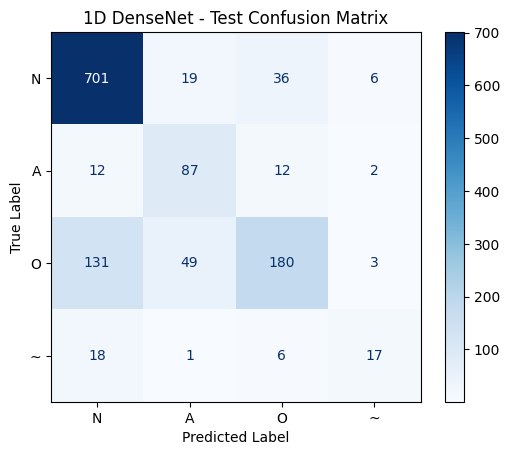

In [15]:
class_names = [
    "N",
    "A",
    "O",
    "~"
]

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "1D DenseNet - Test Confusion Matrix"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Classification Report

In [16]:
print("===== DENSENET CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

===== DENSENET CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           N     0.8132    0.9199    0.8633       762
           A     0.5577    0.7699    0.6468       113
           O     0.7692    0.4959    0.6030       363
           ~     0.6071    0.4048    0.4857        42

    accuracy                         0.7695      1280
   macro avg     0.6868    0.6476    0.6497      1280
weighted avg     0.7714    0.7695    0.7580      1280



## Loss Curve

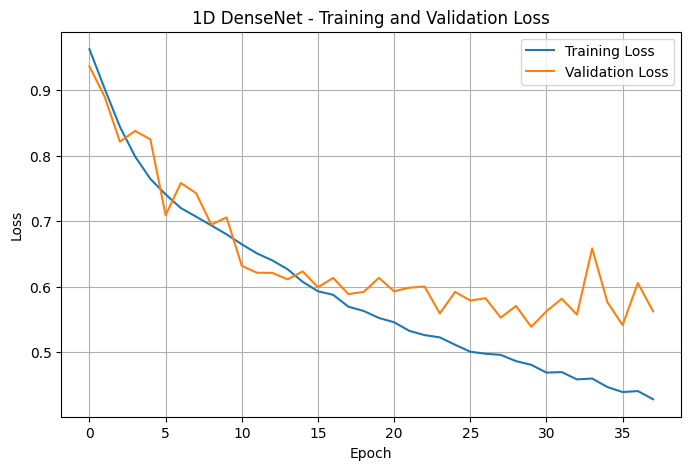

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "1D DenseNet - Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

## Accuracy Curve

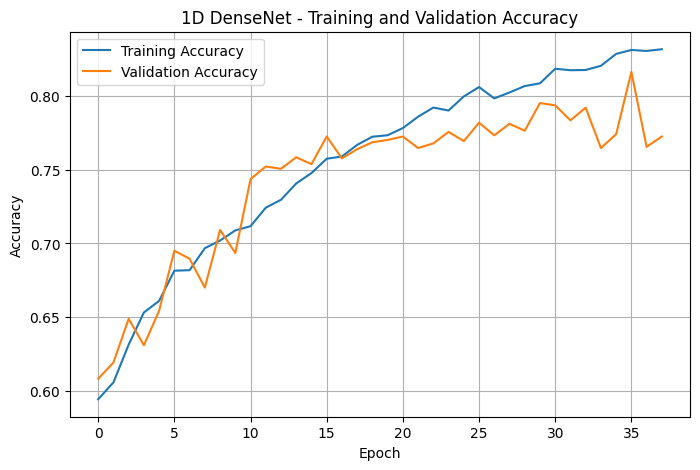

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "1D DenseNet - Training and Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()